In [1]:
#Train 4 models-Random Forest,XGBoost,LightGBM,KNN

In [3]:
import pandas as pd
import numpy as np

from sklearn.model_selection import (
    train_test_split,
    GridSearchCV
)

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier

from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
#load the preprocessed dataset

In [7]:
df = pd.read_csv(
    "cardio_train_preprocessed.csv"
)

TARGET = "cardio"

X = df.drop(columns=[TARGET])
y = df[TARGET]

print("Dataset Shape:", df.shape)

Dataset Shape: (70000, 13)


In [9]:
#train test split

In [11]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Train Shape:", X_train.shape)
print("Test Shape:", X_test.shape)

Train Shape: (56000, 12)
Test Shape: (14000, 12)


In [13]:
#define functions use to evaluate models

In [15]:
def evaluate_model(model, X_test, y_test):

    y_pred = model.predict(X_test)

    y_prob = model.predict_proba(X_test)[:,1]

    accuracy = accuracy_score(
        y_test,
        y_pred
    )

    precision = precision_score(
        y_test,
        y_pred
    )

    recall = recall_score(
        y_test,
        y_pred
    )

    f1 = f1_score(
        y_test,
        y_pred
    )

    roc_auc = roc_auc_score(
        y_test,
        y_prob
    )

    return {
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1 Score": f1,
        "ROC-AUC": roc_auc
    }

In [17]:
#random forest+tunning

In [19]:
rf_param_grid = {
    'n_estimators':[50,100,200],
    'max_depth':[10,20,None],
    'min_samples_split':[2,5],
    'min_samples_leaf':[1,2],
    'max_features':['sqrt','log2']
}

rf_grid = GridSearchCV(
    RandomForestClassifier(
        random_state=42
    ),
    rf_param_grid,
    cv=5,
    scoring='f1',
    n_jobs=-1
)

rf_grid.fit(
    X_train,
    y_train
)

rf_model = rf_grid.best_estimator_

print(
    "RF Best Parameters:",
    rf_grid.best_params_
)

/opt/anaconda3/lib/python3.12/site-packages/joblib/externals/loky/process_executor.py:752: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


RF Best Parameters: {'max_depth': 20, 'max_features': 'sqrt', 'min_samples_leaf': 2, 'min_samples_split': 5, 'n_estimators': 200}


In [21]:
#XGBoost +tunning

In [23]:
xgb_param_grid = {
    'n_estimators':[100,200],
    'max_depth':[3,5,7],
    'learning_rate':[0.01,0.05,0.1],
    'subsample':[0.8,1.0]
}

xgb_grid = GridSearchCV(
    XGBClassifier(
        random_state=42,
        eval_metric='logloss'
    ),
    xgb_param_grid,
    cv=5,
    scoring='f1',
    n_jobs=-1
)

xgb_grid.fit(
    X_train,
    y_train
)

xgb_model = xgb_grid.best_estimator_

print(
    "XGBoost Best Parameters:",
    xgb_grid.best_params_
)

XGBoost Best Parameters: {'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 200, 'subsample': 1.0}


In [25]:
#LightGBM+tunning

In [27]:
lgbm_param_grid = {
    'n_estimators':[100,200],
    'learning_rate':[0.01,0.05,0.1],
    'num_leaves':[31,50,100],
    'max_depth':[-1,5,10]
}

lgbm_grid = GridSearchCV(
    LGBMClassifier(
        random_state=42
    ),
    lgbm_param_grid,
    cv=5,
    scoring='f1',
    n_jobs=-1
)

lgbm_grid.fit(
    X_train,
    y_train
)

lgbm_model = lgbm_grid.best_estimator_

print(
    "LightGBM Best Parameters:",
    lgbm_grid.best_params_
)

[LightGBM] [Info] Number of positive: 22386, number of negative: 22414
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.007906 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 489
[LightGBM] [Info] Number of data points in the train set: 44800, number of used features: 12
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.499688 -> initscore=-0.001250
[LightGBM] [Info] Start training from score -0.001250
[LightGBM] [Info] Number of positive: 22386, number of negative: 22414
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.004984 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 489
[LightGBM] [Info] Number of data points in the train set: 44800, number of used features: 12
[LightGBM] [Info] [b

/opt/anaconda3/lib/python3.12/site-packages/numpy/ma/core.py:2820: RuntimeWarning: invalid value encountered in cast
  _data = np.array(data, dtype=dtype, copy=copy,


[LightGBM] [Info] Number of positive: 27983, number of negative: 28017
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001848 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 498
[LightGBM] [Info] Number of data points in the train set: 56000, number of used features: 12
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.499696 -> initscore=-0.001214
[LightGBM] [Info] Start training from score -0.001214
LightGBM Best Parameters: {'learning_rate': 0.05, 'max_depth': -1, 'n_estimators': 100, 'num_leaves': 31}


In [29]:
#knn+tunning

In [35]:
knn_param_grid = {
    'n_neighbors':[3,5,7,9,11],
    'weights':['uniform','distance'],
    'metric':['euclidean','manhattan']
}
knn_grid = GridSearchCV(
    KNeighborsClassifier(),
    knn_param_grid,
    cv=5,
    scoring='f1',
    n_jobs=-1
)

knn_grid.fit(
    X_train,
    y_train
)

knn_model = knn_grid.best_estimator_

print(
    "KNN Best Parameters:",
    knn_grid.best_params_
)

KNN Best Parameters: {'metric': 'manhattan', 'n_neighbors': 9, 'weights': 'uniform'}


In [37]:
#evaluate all models

In [39]:
results = []

models = {
    "Random Forest": rf_model,
    "XGBoost": xgb_model,
    "LightGBM": lgbm_model,
    "KNN": knn_model
}

for name, model in models.items():

    metrics = evaluate_model(
        model,
        X_test,
        y_test
    )

    metrics["Model"] = name

    results.append(metrics)

results_df = pd.DataFrame(results)

results_df = results_df[
    [
        'Model',
        'Accuracy',
        'Precision',
        'Recall',
        'F1 Score',
        'ROC-AUC'
    ]
]

results_df = results_df.sort_values(
    by='F1 Score',
    ascending=False
)

print(results_df)

           Model  Accuracy  Precision    Recall  F1 Score   ROC-AUC
2       LightGBM  0.790714   0.843528  0.713551  0.773114  0.879715
1        XGBoost  0.790643   0.846311  0.709977  0.772173  0.880251
0  Random Forest  0.784071   0.841852  0.699257  0.763957  0.874842
3            KNN  0.752429   0.780248  0.702401  0.739281  0.833401


In [43]:
#compare performance of models 

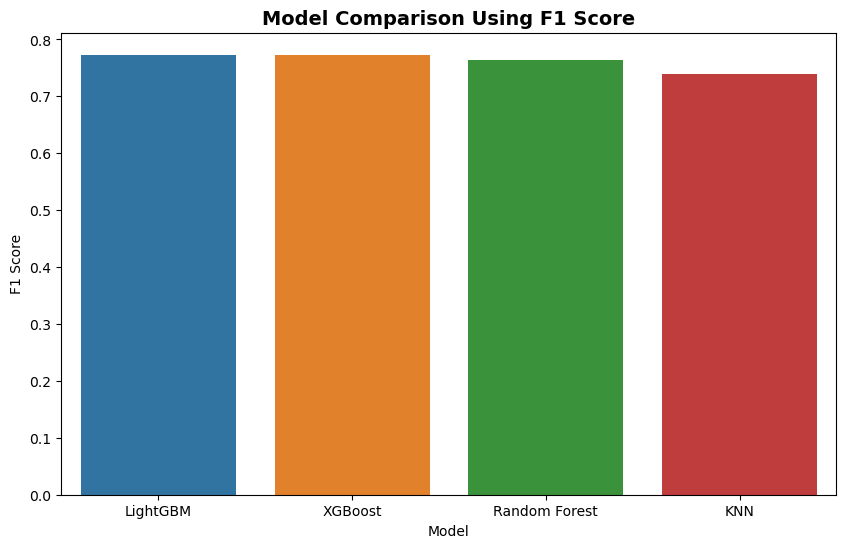

In [45]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=results_df,
    x='Model',
    y='F1 Score',
    hue='Model',
    legend=False
)

plt.title(
    "Model Comparison Using F1 Score",
    fontsize=14,
    fontweight='bold'
)

plt.show()

In [47]:
#confusion matrix for best model-we rank best model acc to F1 score rather than accuracy because it is important 
#to identify positive patients

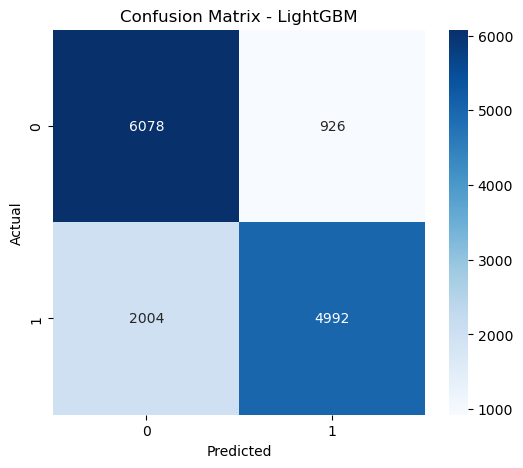

In [49]:
best_model_name = results_df.iloc[0]['Model']

best_model = models[
    best_model_name
]

y_pred = best_model.predict(
    X_test
)

cm = confusion_matrix(
    y_test,
    y_pred
)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title(
    f"Confusion Matrix - {best_model_name}"
)

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [51]:
#save all 4 trained models

In [53]:
import pickle

models = {
    "Random Forest": rf_model,
    "XGBoost": xgb_model,
    "LightGBM": lgbm_model,
    "KNN": knn_model
}

for name, model in models.items():
    file_name = f"{name.lower().replace(' ', '_')}.pkl"
    with open(file_name, 'wb') as file:
        pickle.dump(model, file)

In [55]:
#to see why lightGBM is best model

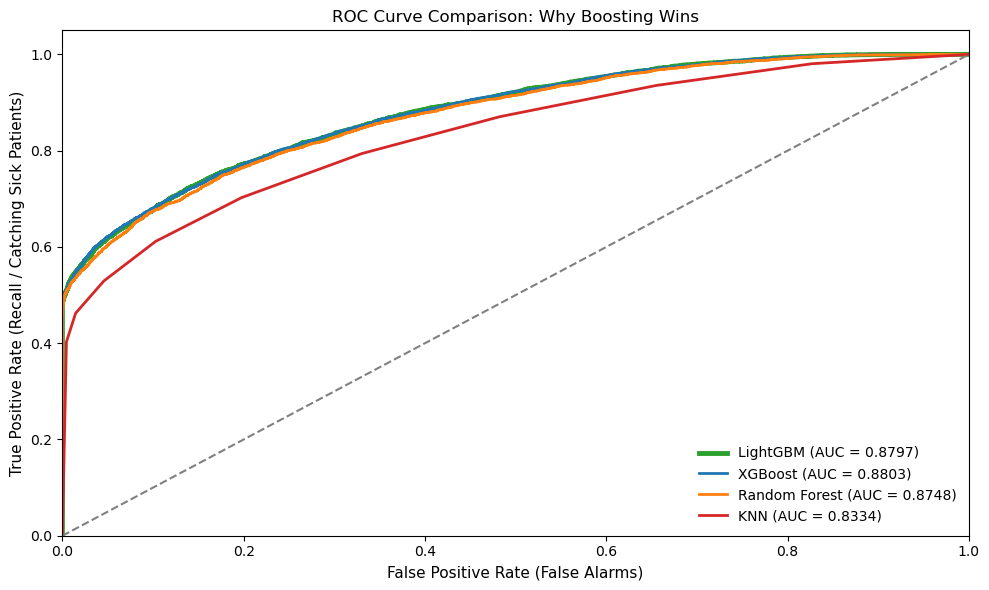

In [59]:
from sklearn.metrics import roc_curve, auc
plt.figure(figsize=(10, 6))

models_dict = {
    "LightGBM": lgbm_model,
    "XGBoost": xgb_model,
    "Random Forest": rf_model,
    "KNN": knn_model
}

colors = {
    "LightGBM": "#2ca02c",   # Green - Highlighted Champion
    "XGBoost": "#1f77b4",    # Blue
    "Random Forest": "#ff7f0e", # Orange
    "KNN": "#d62728"         # Red - Underperformer
}

for name, model in models_dict.items():
    # Get probability predictions for the positive class (CVD Risk)
    y_probs = model.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_probs)
    roc_auc = auc(fpr, tpr)
    line_w = 3.5 if name == "LightGBM" else 2.0
    
    plt.plot(
        fpr, tpr, 
        color=colors[name], 
        lw=line_w, 
        label=f'{name} (AUC = {roc_auc:.4f})'
    )

# Diagonal baseline representing random guessing
plt.plot([0, 1], [0, 1], color='grey', lw=1.5, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (False Alarms)', fontsize=11)
plt.ylabel('True Positive Rate (Recall / Catching Sick Patients)', fontsize=11)
plt.title('ROC Curve Comparison: Why Boosting Wins')
plt.legend(loc="lower right", frameon=True, facecolor='white', edgecolor='none')
plt.tight_layout()
plt.show()

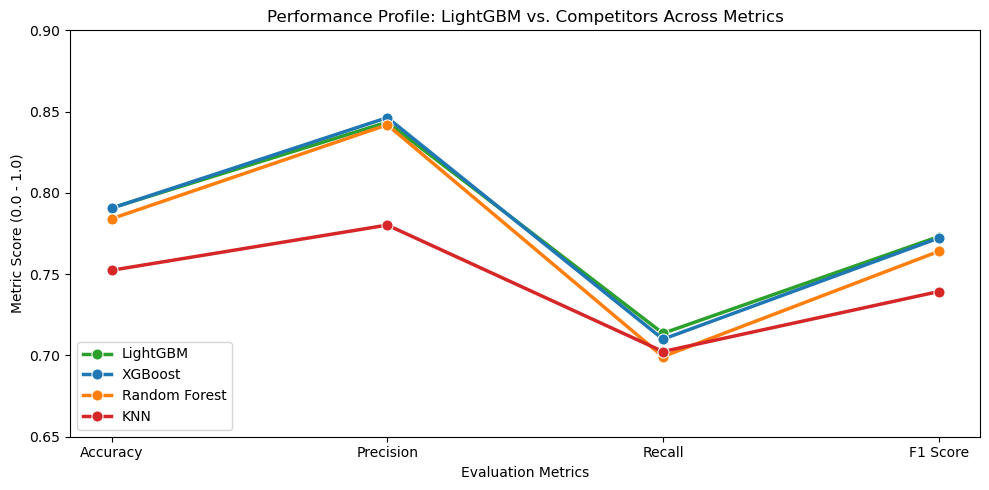

In [61]:
data = {
    'Model': ['LightGBM', 'XGBoost', 'Random Forest', 'KNN'],
    'Accuracy': [0.7907, 0.7906, 0.7841, 0.7524],
    'Precision': [0.8435, 0.8463, 0.8419, 0.7802],
    'Recall': [0.7136, 0.7100, 0.6993, 0.7024],
    'F1 Score': [0.7731, 0.7722, 0.7640, 0.7393]
}
df_metrics = pd.DataFrame(data)
df_melted = df_metrics.melt(id_vars='Model', var_name='Metric', value_name='Score')

plt.figure(figsize=(10, 5))
sns.lineplot(
    data=df_melted, 
    x='Metric', 
    y='Score', 
    hue='Model', 
    palette=colors, 
    marker='o', 
    markersize=8, 
    lw=2.5
)

plt.title('Performance Profile: LightGBM vs. Competitors Across Metrics')
plt.ylabel('Metric Score (0.0 - 1.0)')
plt.xlabel('Evaluation Metrics')
plt.ylim([0.65, 0.90]) # Zoomed in to highlight the crucial differences
plt.legend(loc='lower left')
plt.tight_layout()
plt.show()

In [63]:
#why did we choose LightGBM

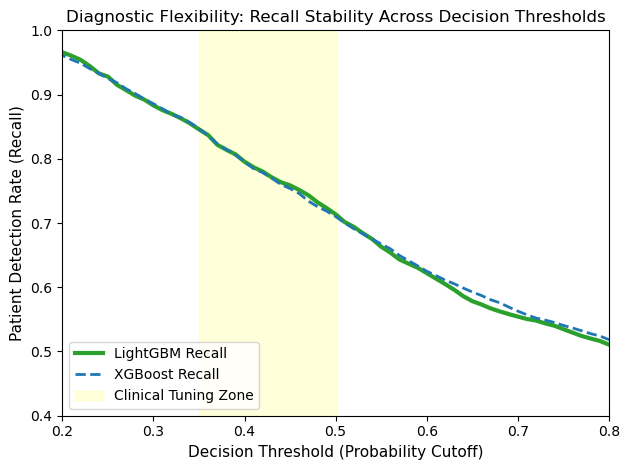

In [67]:
from sklearn.metrics import recall_score
# Generate continuous decision thresholds from 0.1 to 0.9
thresholds = np.linspace(0.1, 0.9, 81)

# Extract predicted probabilities for the positive class (CVD Risk)
lgbm_probs = lgbm_model.predict_proba(X_test)[:, 1]
xgb_probs = xgb_model.predict_proba(X_test)[:, 1]

lgbm_recalls = []
xgb_recalls = []

# Calculate Recall at every single threshold step
for t in thresholds:
    lgbm_recalls.append(recall_score(y_test, (lgbm_probs >= t).astype(int)))
    xgb_recalls.append(recall_score(y_test, (xgb_probs >= t).astype(int)))

# Plot the curves
plt.plot(thresholds, lgbm_recalls, color='#2ca02c', lw=3, label='LightGBM Recall')
plt.plot(thresholds, xgb_recalls, color='#1f77b4', lw=2, linestyle='--', label='XGBoost Recall')

# Highlight the medical screening sweet-spot (Thresholds between 0.35 and 0.50)
plt.axvspan(0.35, 0.50, color='yellow', alpha=0.15, label='Clinical Tuning Zone')

# Labeling and polish
plt.xlabel('Decision Threshold (Probability Cutoff)', fontsize=11)
plt.ylabel('Patient Detection Rate (Recall)', fontsize=11)
plt.title('Diagnostic Flexibility: Recall Stability Across Decision Thresholds')
plt.xlim([0.2, 0.8])  # Zoomed into the practical, realistic operational window
plt.ylim([0.4, 1.0])
plt.legend(loc='lower left', frameon=True, facecolor='white')
plt.tight_layout()
plt.show()
